<a href="https://colab.research.google.com/github/tishamondal-stargazer/Machine-Learning/blob/main/Practical-04-Extra-Developer-Performance/Practical-04-Extra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CS23059 Tisha Mondal

ML Lab-4 Extra Practical

Aim: To implement a Decision Tree regression model on the Developer Performance dataset and analyze how different tree depths and splitting criteria influence model performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
url = "https://raw.githubusercontent.com/tishamondal-stargazer/Machine-Learning/refs/heads/main/datasets/Developer_Performance_dataset_1000%20(1).csv"
df = pd.read_csv(url)

df.head()

,Hours_Coding,Lines_of_Code,Bugs_Found,Bugs_Fixed,AI_Usage_Hours,Sleep_Hours,Cognitive_Load,Coffee_Intake,Stress_Level,Task_Duration_Hours,Commits,Errors,Task_Success_Rate
0,7,416,9,7,6,5.9,92,7,99,10.5,20,3,34
1,4,269,16,13,5,5.1,85,2,100,9.5,17,8,36
2,11,439,3,0,2,6.2,38,2,55,18.3,35,2,79
3,8,472,15,9,4,4.2,26,5,30,12.6,28,4,94
4,5,265,19,16,5,8.1,82,6,82,7.0,25,9,33


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Hours_Coding         1000 non-null   int64  
 1   Lines_of_Code        1000 non-null   int64  
 2   Bugs_Found           1000 non-null   int64  
 3   Bugs_Fixed           1000 non-null   int64  
 4   AI_Usage_Hours       1000 non-null   int64  
 5   Sleep_Hours          1000 non-null   float64
 6   Cognitive_Load       1000 non-null   int64  
 7   Coffee_Intake        1000 non-null   int64  
 8   Stress_Level         1000 non-null   int64  
 9   Task_Duration_Hours  1000 non-null   float64
 10  Commits              1000 non-null   int64  
 11  Errors               1000 non-null   int64  
 12  Task_Success_Rate    1000 non-null   int64  
dtypes: float64(2), int64(11)
memory usage: 101.7 KB


In [5]:
df.shape

(1000, 13)

In [6]:
df.describe()

,Hours_Coding,Lines_of_Code,Bugs_Found,Bugs_Fixed,AI_Usage_Hours,Sleep_Hours,Cognitive_Load,Coffee_Intake,Stress_Level,Task_Duration_Hours,Commits,Errors,Task_Success_Rate
count,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,5.84000,356.23400,9.876000,7.153000,2.961000,6.465800,56.933000,3.368000,66.410000,8.700100,17.253000,4.544000,56.578000
std,3.15854,188.15535,5.796052,5.468226,2.021278,1.439529,21.767506,2.342234,21.865452,5.992891,10.836901,2.820997,20.814879
min,1.00000,26.00000,0.000000,0.000000,0.000000,4.000000,20.000000,0.000000,30.000000,0.500000,1.000000,0.000000,30.000000
25%,3.00000,209.50000,5.000000,2.000000,1.000000,5.200000,38.000000,1.000000,48.000000,4.000000,9.000000,2.000000,37.000000
50%,6.00000,332.00000,10.000000,7.000000,3.000000,6.400000,57.000000,3.000000,66.000000,7.450000,14.000000,5.000000,55.500000
75%,9.00000,480.50000,15.000000,12.000000,5.000000,7.700000,76.000000,5.000000,86.000000,12.000000,23.000000,7.000000,74.000000
max,11.00000,993.00000,19.000000,19.000000,6.000000,9.000000,94.000000,7.000000,100.000000,27.500000,50.000000,9.000000,100.000000


In [7]:
df.columns

Index(['Hours_Coding', 'Lines_of_Code', 'Bugs_Found', 'Bugs_Fixed',
       'AI_Usage_Hours', 'Sleep_Hours', 'Cognitive_Load', 'Coffee_Intake',
       'Stress_Level', 'Task_Duration_Hours', 'Commits', 'Errors',
       'Task_Success_Rate'],
      dtype='object')

In [8]:
df.isnull().sum()

,0
Hours_Coding,0
Lines_of_Code,0
Bugs_Found,0
Bugs_Fixed,0
AI_Usage_Hours,0
Sleep_Hours,0
Cognitive_Load,0
Coffee_Intake,0
Stress_Level,0
Task_Duration_Hours,0


In [9]:
before_rows = df.shape[0]
df = df.dropna()
after_rows = df.shape[0]

print("Before rows:", before_rows)
print("After rows:", after_rows)
print("Dropped rows:", before_rows - after_rows)

Before rows: 1000
After rows: 1000
Dropped rows: 0


In [10]:
df.columns

Index(['Hours_Coding', 'Lines_of_Code', 'Bugs_Found', 'Bugs_Fixed',
       'AI_Usage_Hours', 'Sleep_Hours', 'Cognitive_Load', 'Coffee_Intake',
       'Stress_Level', 'Task_Duration_Hours', 'Commits', 'Errors',
       'Task_Success_Rate'],
      dtype='object')

In [11]:
y = df['Task_Success_Rate']      # Target variable
X = df.drop('Task_Success_Rate', axis=1)   # Features

In [12]:
print(X.shape)
print(y.shape)

(1000, 12)
(1000,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, test_size=0.3, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (700, 12)
Testing set: (300, 12)


In [14]:
regressor = DecisionTreeRegressor(
    criterion='squared_error',
    max_depth=5,
    random_state=42
)

regressor.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [15]:
y_pred = regressor.predict(X_test)

print("Predicted values:")
print(y_pred)

Predicted values:
[43.44230769 31.14705882 34.88888889 43.44230769 73.66666667 31.14705882
 62.76470588 66.72       62.76470588 34.88888889 54.29411765 51.33333333
 58.44827586 80.05882353 46.66666667 30.04109589 53.30769231 72.42424242
 80.65714286 90.76       58.44827586 47.25       56.67741935 56.67741935
 66.75       43.44230769 90.76       42.04       63.88461538 33.26315789
 33.26315789 80.05882353 43.44230769 95.04166667 80.65714286 58.44827586
 66.75       76.38461538 43.44230769 53.30769231 30.04109589 80.05882353
 80.65714286 53.30769231 80.65714286 74.90909091 30.04109589 43.44230769
 48.54545455 74.90909091 43.44230769 54.29411765 72.42424242 62.76470588
 43.44230769 63.88461538 63.88461538 72.42424242 30.04109589 48.54545455
 34.88888889 72.42424242 58.44827586 73.66666667 38.04545455 90.76
 30.04109589 54.29411765 31.14705882 62.76470588 84.25       80.65714286
 30.04109589 38.04545455 30.04109589 90.76       43.44230769 38.04545455
 33.26315789 48.54545455 43.44230769 80

In [16]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 34.499508816321686
R2 Score: 0.914034367708818


In [17]:
depths = [2, 5, 10, 15]

for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("Depth:", depth)
    print("R2 Score:", r2_score(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("----------------------------")

Depth: 2
R2 Score: 0.8207170605084363
MSE: 71.94937310127497
----------------------------
Depth: 5
R2 Score: 0.914034367708818
MSE: 34.499508816321686
----------------------------
Depth: 10
R2 Score: 0.874285124393865
MSE: 50.4515740037373
----------------------------
Depth: 15
R2 Score: 0.8772542800765845
MSE: 49.26
----------------------------


In [18]:
criteria = ['squared_error', 'absolute_error', 'friedman_mse']

for crit in criteria:
    model = DecisionTreeRegressor(criterion=crit, max_depth=5, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("Criterion:", crit)
    print("R2 Score:", r2_score(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("----------------------------")

Criterion: squared_error
R2 Score: 0.914034367708818
MSE: 34.499508816321686
----------------------------
Criterion: absolute_error
R2 Score: 0.9032395273888327
MSE: 38.83166666666666
----------------------------
Criterion: friedman_mse
R2 Score: 0.914034367708818
MSE: 34.499508816321686
----------------------------


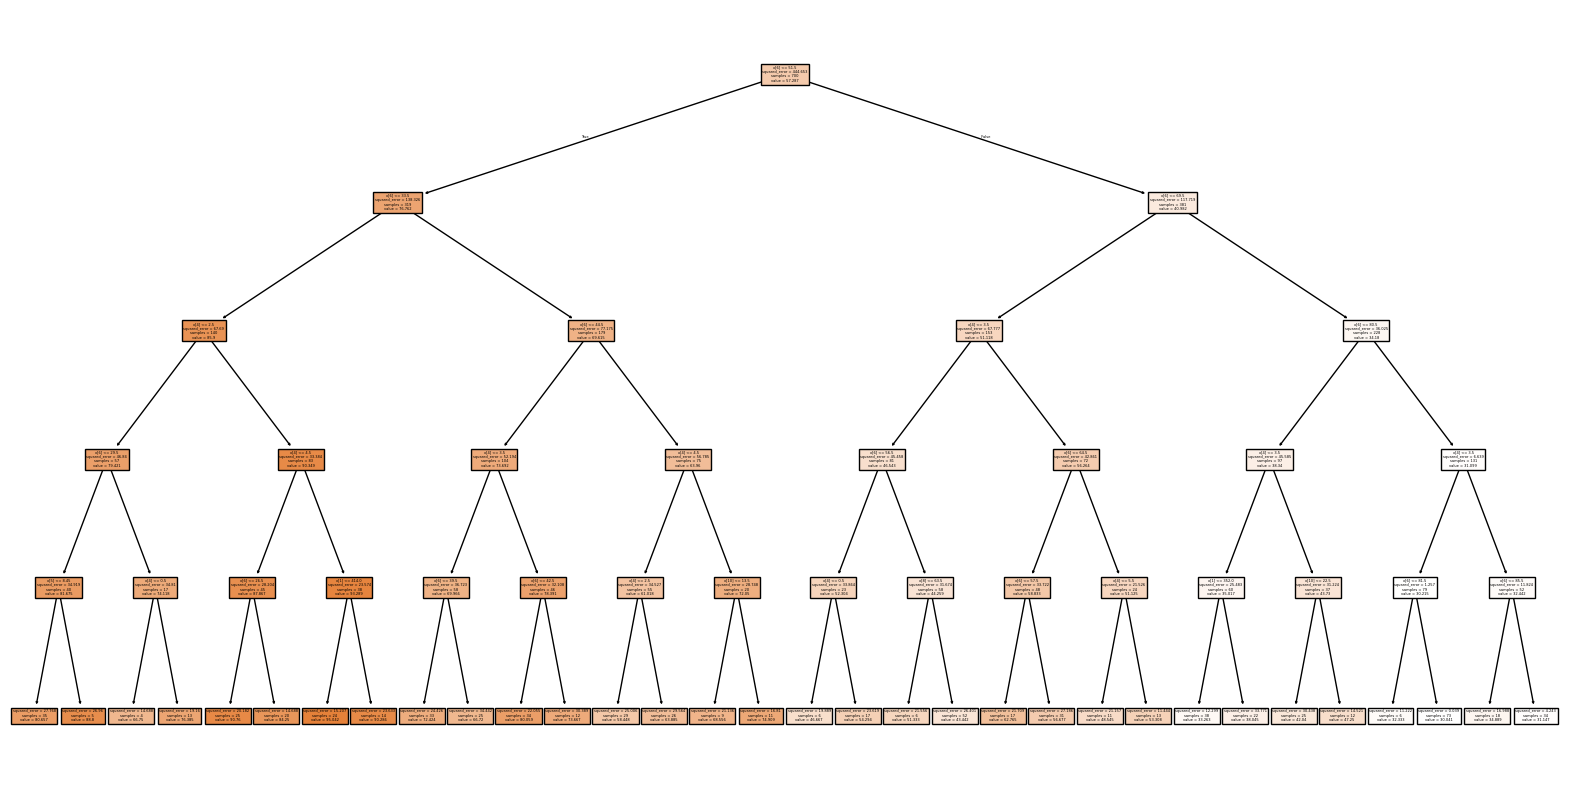

In [19]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
tree.plot_tree(regressor, filled=True)
plt.show()